In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score

from xgboost import XGBRegressor
from catboost import CatBoostRegressor, Pool

import lightgbm as lgb

In [71]:
df = pd.read_csv('california_housing_data.csv')
df.head()

# Info dataset
df.info()

# Statistiche descrittive
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Ho tutti numeri (niente stringhe) non nulli -> niente pulizia

## Outlier

In [72]:
# Calcolo Q1 e Q3
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

# Mantengo solo i dati senza outlier
df_clean = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [73]:
# Info dataset
df_clean.info()

# Statistiche descrittive
df_clean.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 16312 entries, 2 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       16312 non-null  float64
 1   HouseAge     16312 non-null  float64
 2   AveRooms     16312 non-null  float64
 3   AveBedrms    16312 non-null  float64
 4   Population   16312 non-null  float64
 5   AveOccup     16312 non-null  float64
 6   Latitude     16312 non-null  float64
 7   Longitude    16312 non-null  float64
 8   MedHouseVal  16312 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000
mean,3.657930,29.447155,5.156007,1.047226,1271.783227,2.865163,35.670947,-119.626930,1.927436
std,1.444641,12.194464,1.043588,0.066569,627.384658,0.624931,2.140620,1.995143,0.943917
min,0.536000,1.000000,2.032738,0.866013,5.000000,1.161290,32.540000,-124.350000,0.149990
25%,2.561150,19.000000,4.426033,1.002732,814.000000,2.437060,33.940000,-121.820000,1.185000
50%,3.494650,30.000000,5.142857,1.043733,1160.000000,2.814886,34.290000,-118.610000,1.775000
75%,4.583300,38.000000,5.850487,1.088686,1637.000000,3.245208,37.730000,-118.030000,2.494000
max,8.011300,52.000000,8.452915,1.239521,3132.000000,4.560748,41.950000,-114.570000,4.822000


## Featuring Engineering

In [74]:
# --- Feature derivate di base ---
# Relazioni dirette tra dimensione della casa, età e popolazione

df_clean["Rooms_per_HouseAge"] = df_clean["AveRooms"] / df_clean["HouseAge"]
# -> quante stanze ci sono mediamente in relazione all’età delle case.
#   Case più nuove con molte stanze potrebbero indicare aree più ricche.

df_clean["Bedrooms_per_Room"] = df_clean["AveBedrms"] / df_clean["AveRooms"]
# -> proporzione di camere da letto sul totale delle stanze.
#   Valori alti indicano case più “familiari”, valori bassi case più spaziose o moderne.

df_clean["Population_per_HouseAge"] = df_clean["Population"] / df_clean["HouseAge"]
# -> popolazione relativa all’età delle case: zone più vecchie ma molto popolate
#   possono avere un mercato immobiliare diverso da zone nuove e meno dense.

df_clean["Bedrooms_per_Person"] = df_clean["AveBedrms"] / df_clean["Population"]
# -> quante camere da letto per abitante medio: misura indiretta di comfort e densità abitativa.


# --- Distanza geografica ---
df_clean["Distance_from_Center"] = np.sqrt((df_clean["Longitude"] + 119.4179)**2 + (df_clean["Latitude"] - 36.7783)**2)
# -> distanza dal centro geografico della California.
#   Serve come proxy per distinguere zone centrali da zone periferiche (che spesso hanno prezzi diversi).


# --- Trasformazioni per ridurre la skewness ---
df_clean["MedInc_log"] = np.log1p(df_clean["MedInc"])
# -> logaritmo del reddito medio per ridurre l’effetto di valori estremi.

df_clean["HouseAge_sqrt"] = np.sqrt(df_clean["HouseAge"])
# -> radice quadrata dell’età della casa: attenua la crescita troppo rapida di case molto vecchie.


# --- Relazioni tra densità e popolazione ---
df_clean["People_per_Room"] = df_clean["Population"] / (df_clean["AveRooms"] + 1e-5)
# -> quante persone mediamente per stanza: misura di sovraffollamento.

df_clean["Rooms_per_Person"] = df_clean["AveRooms"] / (df_clean["Population"] + 1e-5)
# -> opposto di sopra: più alto -> più spazio per persona.

df_clean["Bedrooms_per_Person"] = df_clean["AveBedrms"] / (df_clean["Population"] + 1e-5)
# -> camere da letto per abitante: correlata a comfort abitativo e classe sociale.


# --- Relazioni socio-economiche ---
df_clean["Income_per_HouseAge"] = df_clean["MedInc"] / (df_clean["HouseAge"] + 1)
# -> reddito medio per anno di età della casa:
#   zone con case vecchie ma redditi alti potrebbero indicare quartieri “storici” e costosi.

df_clean["Income_x_HouseAge"] = df_clean["MedInc"] * df_clean["HouseAge"]
# -> interazione diretta reddito × età casa, per catturare effetti combinati.


# --- Interazioni strutturali ---
df_clean["MedInc_x_AveRooms"] = df_clean["MedInc"] * df_clean["AveRooms"]
# -> reddito medio moltiplicato per numero medio di stanze: misura del livello economico + dimensione.

df_clean["MedInc_x_AveBedrms"] = df_clean["MedInc"] * df_clean["AveBedrms"]
# -> simile, ma specifica sulle camere da letto.

df_clean["AveRooms_x_Age"] = df_clean["AveRooms"] * df_clean["HouseAge"]
# -> interazione età × dimensione: case più grandi e vecchie possono comportarsi in modo diverso nel mercato.


# --- Trasformazioni polinomiali leggere ---
df_clean["MedInc_sq"] = df_clean["MedInc"] ** 2
# -> quadrato del reddito medio: cattura effetti non lineari (es. prezzi che crescono più che proporzionalmente al reddito).

df_clean["HouseAge_sq"] = df_clean["HouseAge"] ** 2
# -> quadrato dell’età della casa: utile se il prezzo cala più rapidamente per case molto vecchie.

df_clean["AveRooms_sq"] = df_clean["AveRooms"] ** 2
# -> quadrato del numero medio di stanze: cattura variazioni di prezzo tra case piccole e molto grandi.


# --- Feature geografiche avanzate ---
df_clean["Lat_plus_Lon"] = df_clean["Latitude"] + df_clean["Longitude"]
df_clean["Lat_minus_Lon"] = df_clean["Latitude"] - df_clean["Longitude"]
# -> combinazioni lineari di latitudine e longitudine:
#   i modelli lineari possono così stimare variazioni di prezzo lungo assi geografici (es. nord-sud, est-ovest).

# Creazione di cluster geografici (zone simili per posizione)
from sklearn.cluster import KMeans
coords = df_clean[["Latitude", "Longitude"]]
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_clean["GeoCluster"] = kmeans.fit_predict(coords)
# -> assegna ogni riga a una “zona geografica” (1–5), utile per modelli che non gestiscono bene le coordinate continue.


# --- Indicatori binari / non lineari ---
df_clean["Is_Old_House"] = (df_clean["HouseAge"] > df_clean["HouseAge"].median()).astype(int)
# -> 1 se la casa è più vecchia della mediana del dataset.
#   Permette di catturare il “salto” di prezzo tra case vecchie e nuove.

df_clean["Is_High_Income"] = (df_clean["MedInc"] > df_clean["MedInc"].median()).astype(int)
# -> 1 se il reddito medio è sopra la mediana.
#   Aiuta i modelli a distinguere aree ad alto reddito da quelle a basso reddito.


# --- Distanza dalla costa ---
df_clean["Distance_from_Coast"] = np.abs(df_clean["Longitude"] + 122)
# -> Calcola quanto la località è lontana (in gradi longitudinali) dalla costa californiana.
#   La costa ovest si trova intorno a -122, quindi località con valori piccoli sono vicine all’oceano.
#   In California, la vicinanza alla costa spesso aumenta il valore degli immobili.


# --- Densità popolazione geografica ---
df_clean["Pop_density_geo"] = df_clean["Population"] / (
    (df_clean["Latitude"] - df_clean["Latitude"].mean())**2 +
    (df_clean["Longitude"] - df_clean["Longitude"].mean())**2 + 1
)
# -> Misura una densità "spaziale" della popolazione rispetto al centro geografico medio del dataset.
#   Le zone molto popolate e vicine al centro avranno valori più alti.
#   Utile per catturare l’effetto “densità urbana” (più popolazione -> prezzi più alti).


# --- Interazioni reddito × posizione ---
df_clean["Income_x_Lat"] = df_clean["MedInc"] * df_clean["Latitude"]
# -> Combina reddito medio e latitudine:
#   permette al modello di cogliere differenze economiche tra nord e sud della California.

df_clean["Income_x_Lon"] = df_clean["MedInc"] * df_clean["Longitude"]
# -> Combina reddito medio e longitudine:
#   utile per distinguere aree costiere (più a ovest, longitudini minori) da quelle interne.

In [75]:
# Info dataset
df_clean.info()

# Statistiche descrittive
df_clean.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 16312 entries, 2 to 20639
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   MedInc                   16312 non-null  float64
 1   HouseAge                 16312 non-null  float64
 2   AveRooms                 16312 non-null  float64
 3   AveBedrms                16312 non-null  float64
 4   Population               16312 non-null  float64
 5   AveOccup                 16312 non-null  float64
 6   Latitude                 16312 non-null  float64
 7   Longitude                16312 non-null  float64
 8   MedHouseVal              16312 non-null  float64
 9   Rooms_per_HouseAge       16312 non-null  float64
 10  Bedrooms_per_Room        16312 non-null  float64
 11  Population_per_HouseAge  16312 non-null  float64
 12  Bedrooms_per_Person      16312 non-null  float64
 13  Distance_from_Center     16312 non-null  float64
 14  MedInc_log               16

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,Rooms_per_HouseAge,...,AveRooms_sq,Lat_plus_Lon,Lat_minus_Lon,GeoCluster,Is_Old_House,Is_High_Income,Distance_from_Coast,Pop_density_geo,Income_x_Lat,Income_x_Lon
count,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,...,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000
mean,3.657930,29.447155,5.156007,1.047226,1271.783227,2.865163,35.670947,-119.626930,1.927436,0.239425,...,27.673415,-83.955983,155.297877,1.001839,0.487433,0.500000,2.530349,205.096701,130.238691,-437.615580
std,1.444641,12.194464,1.043588,0.066569,627.384658,0.624931,2.140620,1.995143,0.943917,0.231972,...,10.981325,0.768776,4.066287,1.146921,0.499857,0.500015,1.791464,207.427929,51.491604,173.075777
min,0.536000,1.000000,2.032738,0.866013,5.000000,1.161290,32.540000,-124.350000,0.149990,0.041715,...,4.132024,-85.870000,147.400000,0.000000,0.000000,0.000000,0.000000,0.165149,17.554000,-980.524974
25%,2.561150,19.000000,4.426033,1.002732,814.000000,2.437060,33.940000,-121.820000,1.185000,0.125075,...,19.589769,-84.420000,151.970000,0.000000,0.000000,0.000000,0.520000,80.565935,91.438980,-548.192860
50%,3.494650,30.000000,5.142857,1.043733,1160.000000,2.814886,34.290000,-118.610000,1.775000,0.170932,...,26.448980,-84.180000,152.990000,1.000000,0.000000,0.500000,3.390000,144.206589,123.718439,-417.058207
75%,4.583300,38.000000,5.850487,1.088686,1637.000000,3.245208,37.730000,-118.030000,2.494000,0.273300,...,34.228194,-83.550000,159.710000,1.000000,1.000000,1.000000,3.970000,248.109505,162.705937,-306.559496
max,8.011300,52.000000,8.452915,1.239521,3132.000000,4.560748,41.950000,-114.570000,4.822000,5.533333,...,71.451769,-79.330000,166.140000,4.000000,1.000000,1.000000,7.430000,2453.346073,306.752677,-61.436320


## Matrice di correlazione

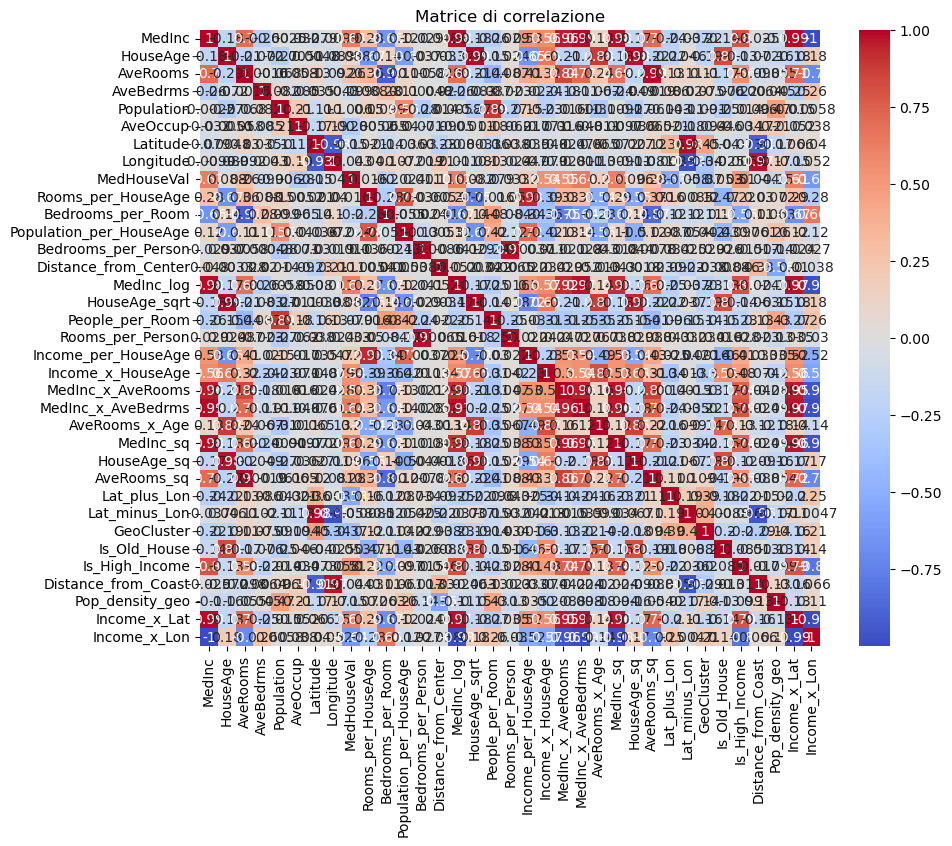

In [76]:
# Calcolo
corr = df_clean.corr(numeric_only=True)
corr

# Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matrice di correlazione")

plt.show()
# MedInc è molto correlato a MedHouseVal (forte segno +)
# AveBedrms cresce fortemente con AveRooms
# Latitude/Longitude -> gradienti geografici

In [77]:
display(corr)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,Rooms_per_HouseAge,...,AveRooms_sq,Lat_plus_Lon,Lat_minus_Lon,GeoCluster,Is_Old_House,Is_High_Income,Distance_from_Coast,Pop_density_geo,Income_x_Lat,Income_x_Lon
MedInc,1.000000,-0.181014,0.698658,-0.256522,-0.002466,-0.031503,-0.078629,-0.009936,0.632971,0.284833,...,0.710105,-0.244724,-0.036517,-0.220993,-0.139153,0.804407,-0.024785,-0.103181,0.987782,-0.998963
HouseAge,-0.181014,1.000000,-0.209684,-0.071658,-0.272499,-0.005069,0.004834,-0.088993,0.087911,-0.669724,...,-0.221328,-0.217496,0.046210,-0.194661,0.834447,-0.133045,-0.071505,-0.155474,-0.179178,0.176889
AveRooms,0.698658,-0.209684,1.000000,-0.001579,-0.067882,0.057669,0.131869,-0.092256,0.260237,0.356873,...,0.990569,0.127758,0.114686,0.110168,-0.174600,0.556880,-0.098199,-0.055429,0.711974,-0.700312
AveBedrms,-0.256522,-0.071658,-0.001579,1.000000,0.082117,-0.085343,0.034775,-0.004277,-0.099079,0.088230,...,0.001873,0.085729,0.020405,0.075072,-0.076436,-0.223426,0.006420,0.044550,-0.251855,0.255983
Population,-0.002466,-0.272499,-0.067882,0.082117,1.000000,0.209546,-0.113037,0.104769,-0.005995,0.152374,...,-0.060784,-0.042849,-0.110912,-0.091244,-0.249139,-0.013672,0.096072,0.472128,-0.015002,0.005823
AveOccup,-0.031503,-0.005069,0.057669,-0.085343,0.209546,1.000000,-0.166071,0.186429,-0.275504,-0.005236,...,0.064857,0.021410,-0.178897,-0.094447,0.046469,-0.034085,0.171516,0.209835,-0.051629,0.038052
Latitude,-0.078629,0.004834,0.131869,0.034775,-0.113037,-0.166071,1.000000,-0.933286,-0.150479,0.021298,...,0.115793,0.362371,0.984352,0.452149,-0.040349,-0.072952,-0.910850,-0.166245,0.066287,0.039782
Longitude,-0.009936,-0.088993,-0.092256,-0.004277,0.104769,0.186429,-0.933286,1.000000,-0.043103,0.040250,...,-0.081465,-0.003470,-0.981966,-0.335306,-0.025453,-0.005837,0.971345,0.170832,-0.149614,0.052282
MedHouseVal,0.632971,0.087911,0.260237,-0.099079,-0.005995,-0.275504,-0.150479,-0.043103,1.000000,0.016494,...,0.284524,-0.530863,-0.058068,-0.373214,0.053450,0.506971,-0.044441,-0.150461,0.614789,-0.635012
Rooms_per_HouseAge,0.284833,-0.669724,0.356873,0.088230,0.152374,-0.005236,0.021298,0.040250,0.016494,1.000000,...,0.368180,0.163761,-0.008536,0.119249,-0.467433,0.223731,0.029863,0.071542,0.285478,-0.281836


# MACHINE LEARNING MODEL

## Separazione variabili

In [78]:
# X (features/caratteristiche) -> tutte le colonne che userai per fare la predizione
# y (target) -> la colonna che vuoi predire, cioè il prezzo della casa

X = df_clean.drop(["MedHouseVal", "Population", "AveOccup"], axis=1) # caratteristiche -> prendo tutte le colonne tranne quelle indicate
y = df_clean["MedHouseVal"] # target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Visualizzazione della standardizzazione

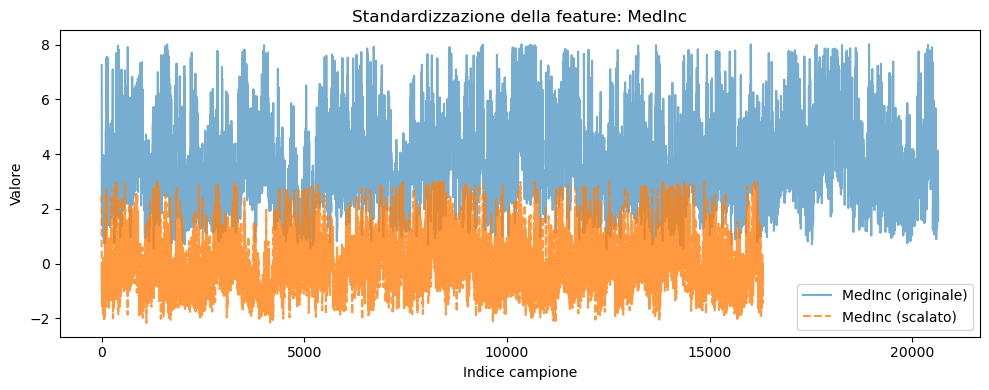

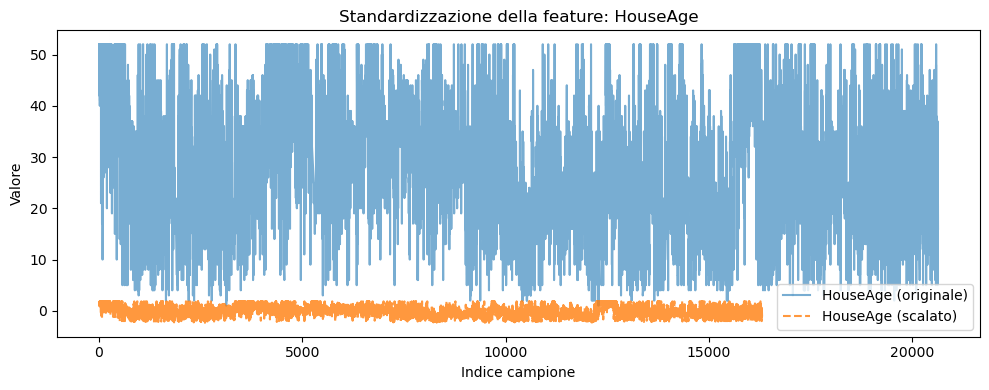

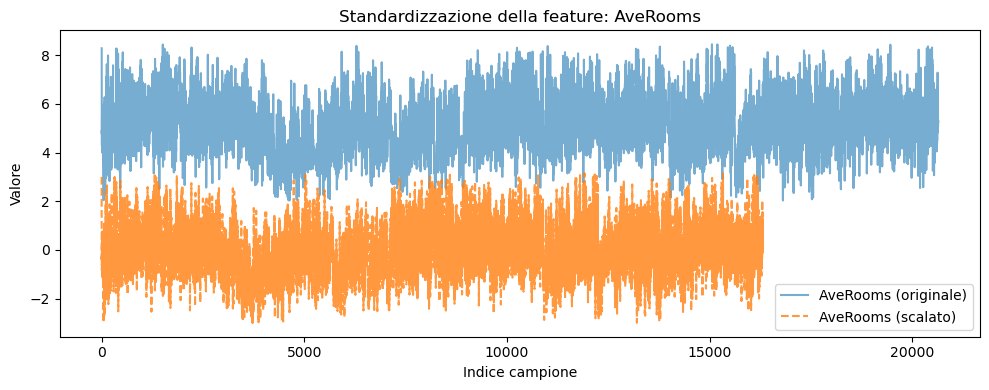

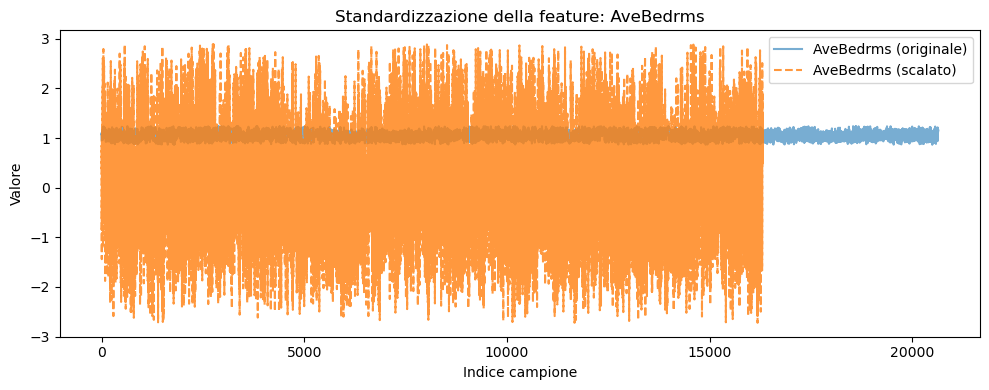

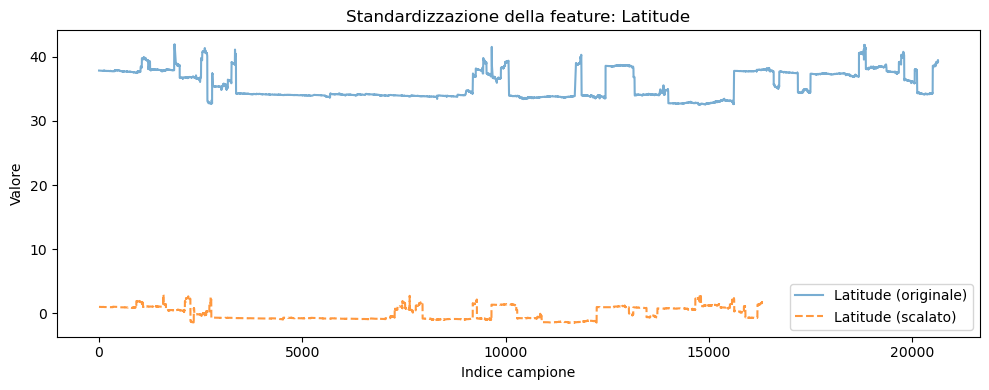

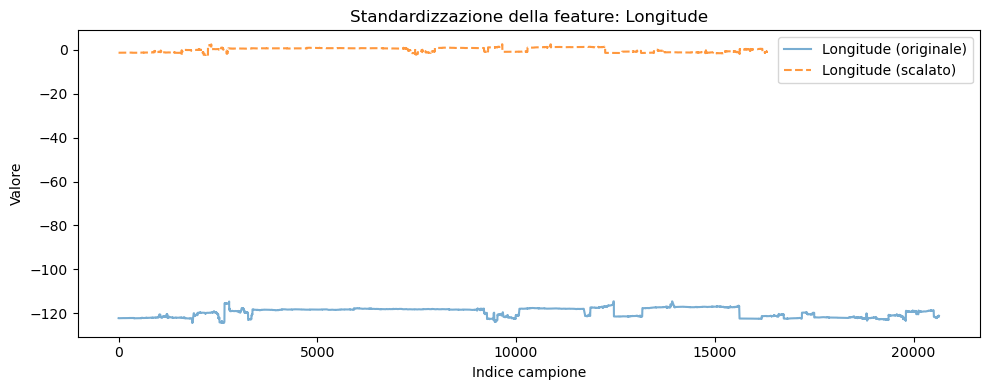

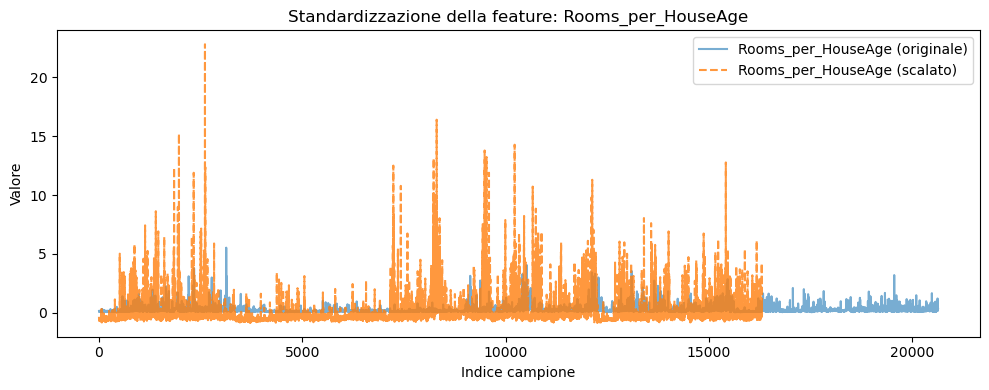

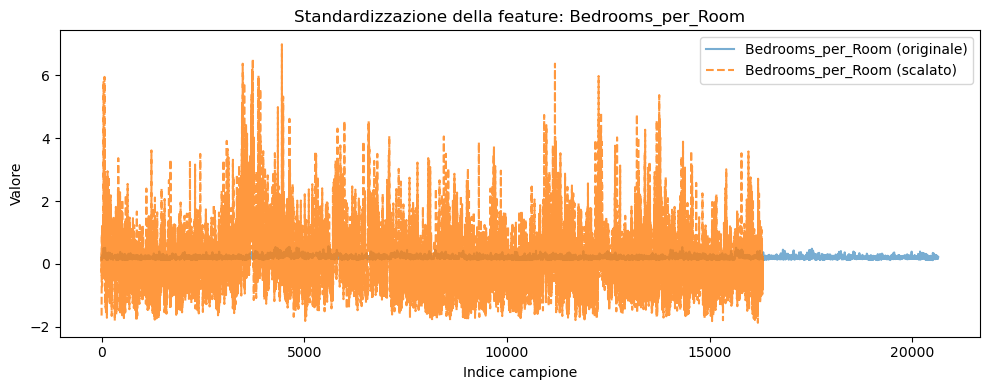

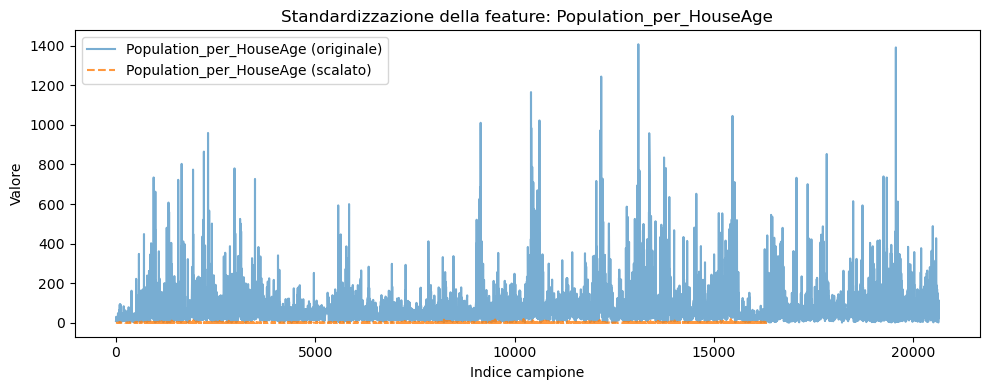

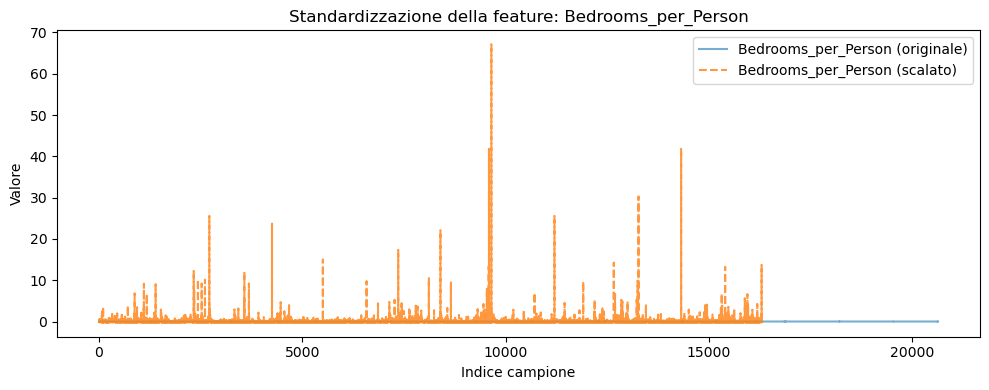

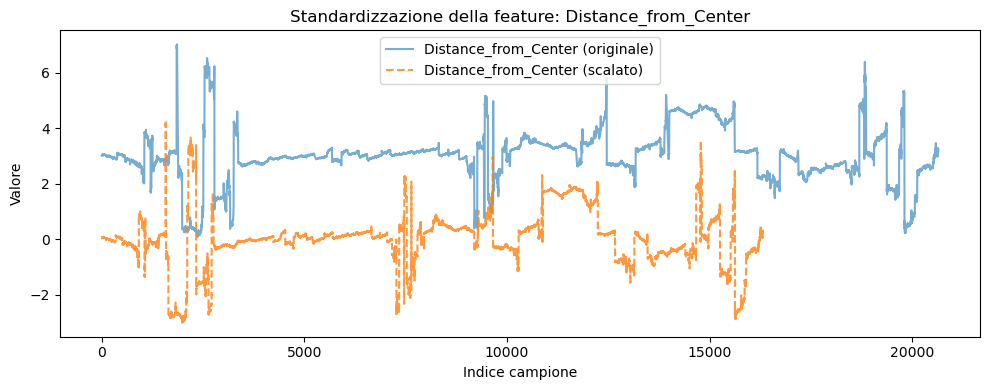

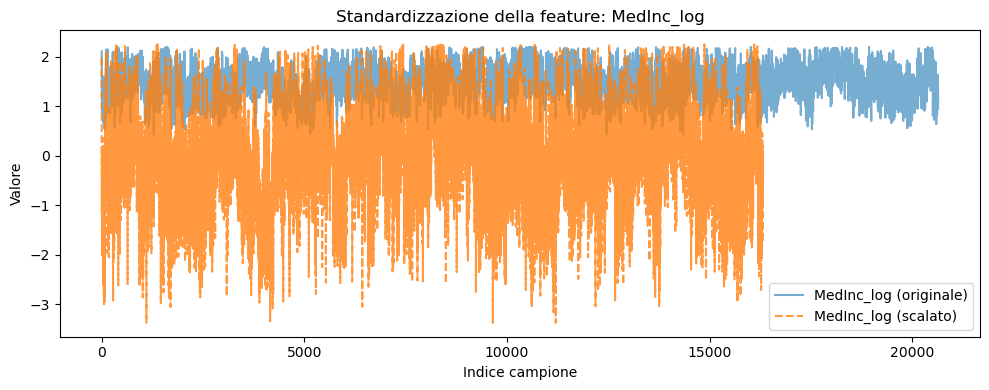

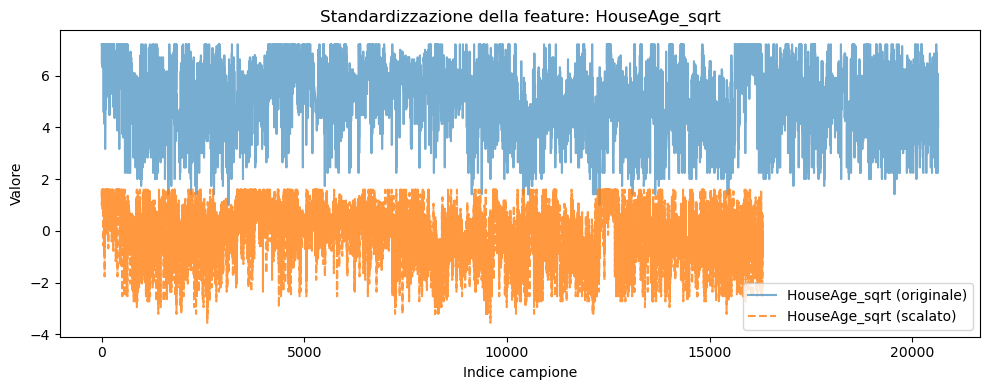

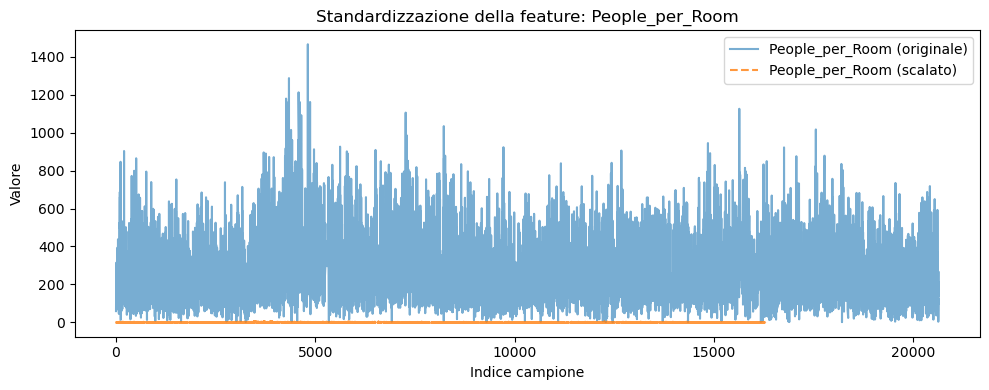

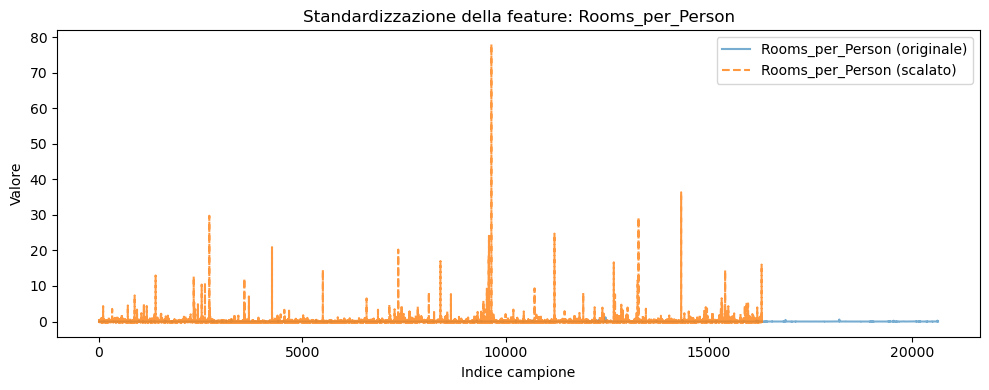

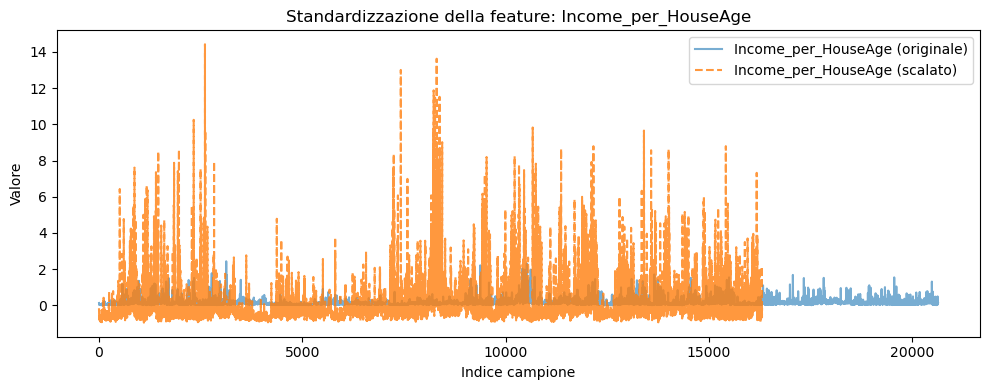

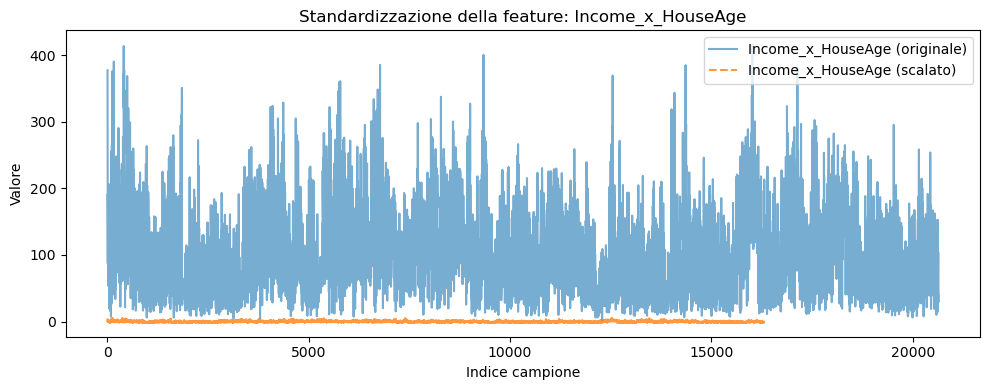

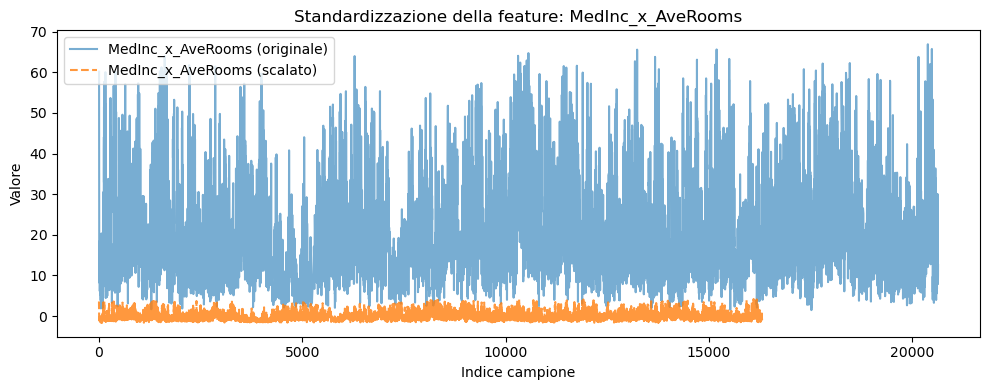

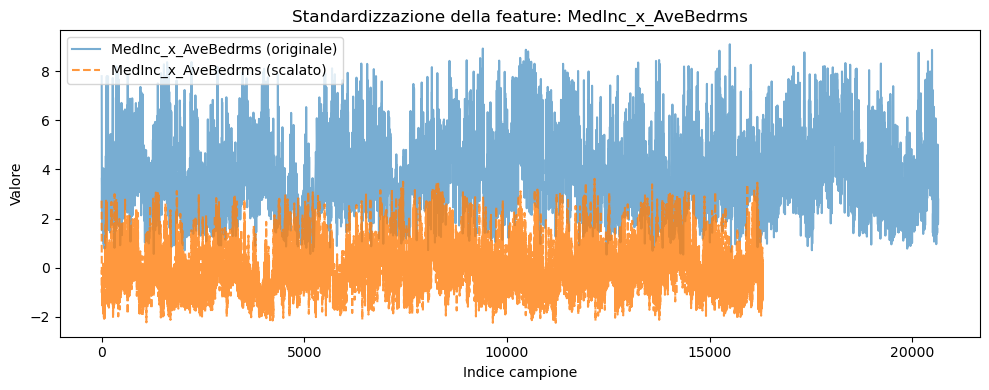

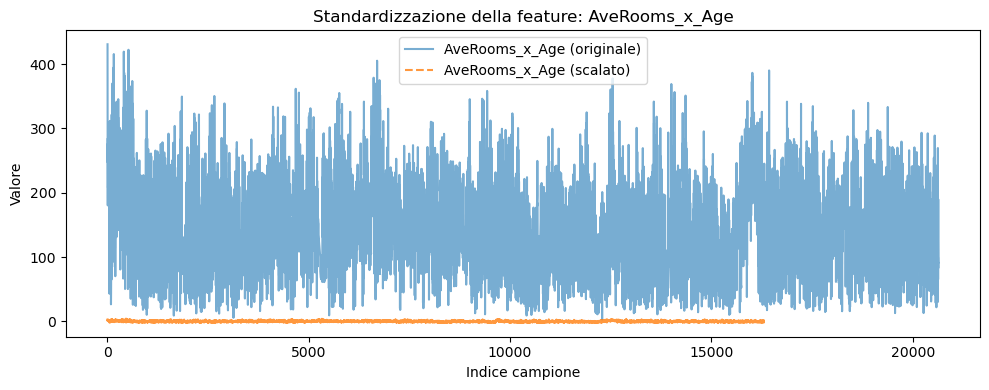

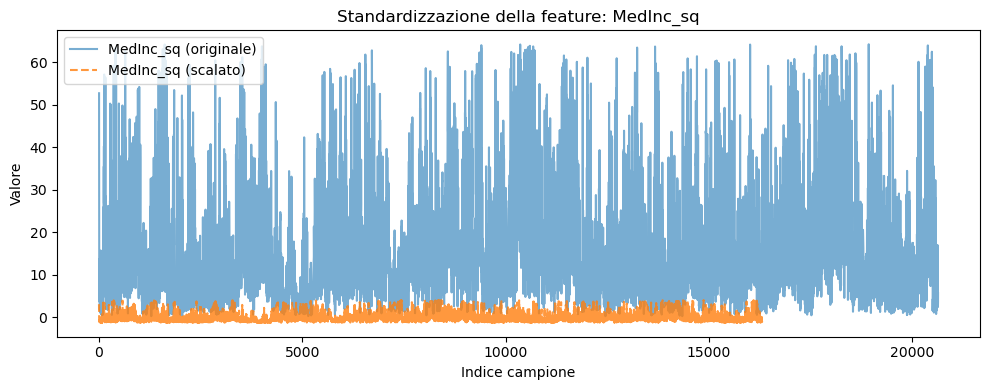

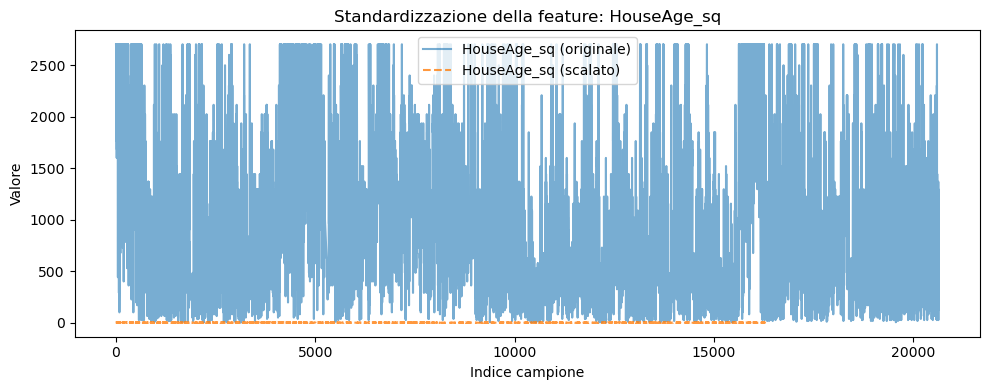

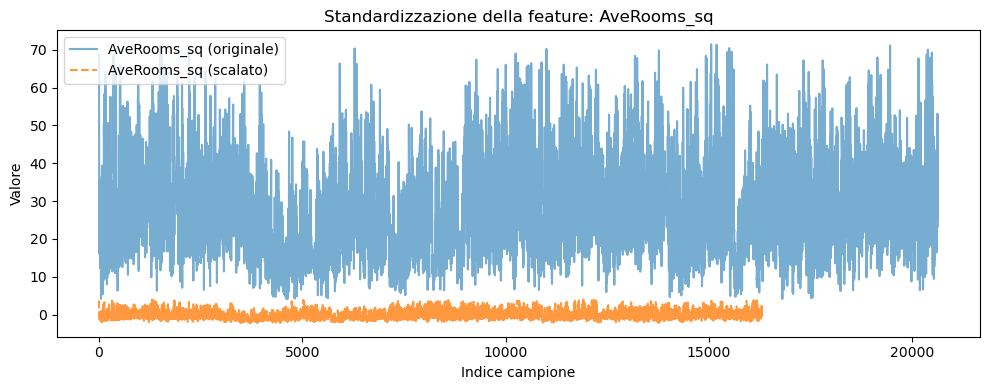

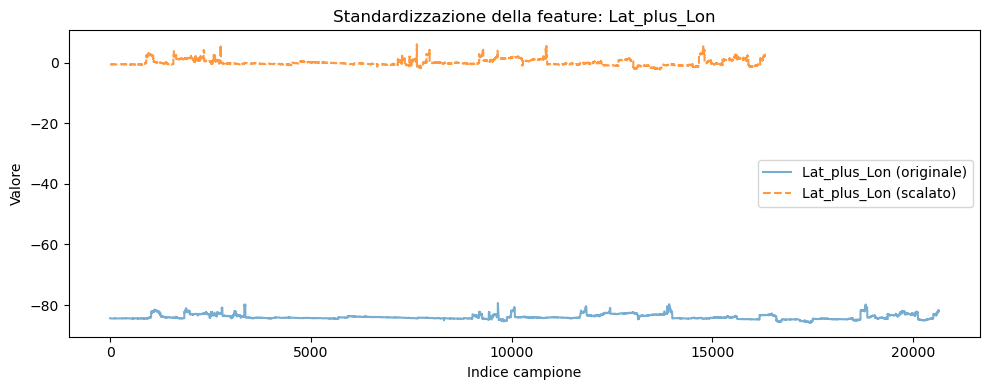

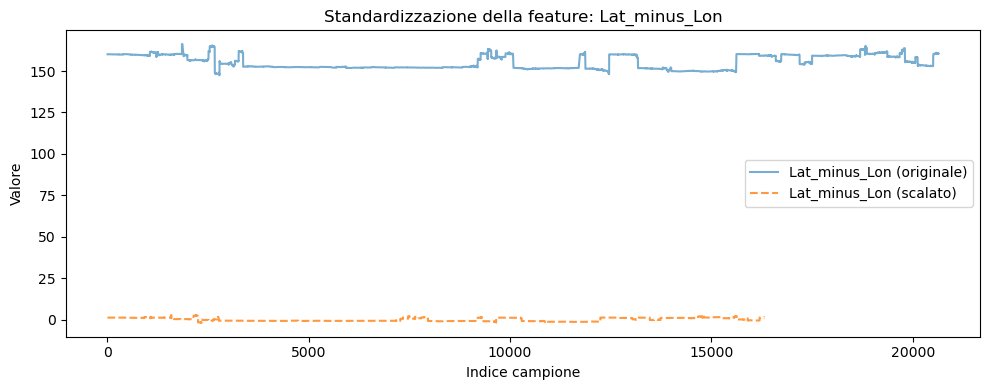

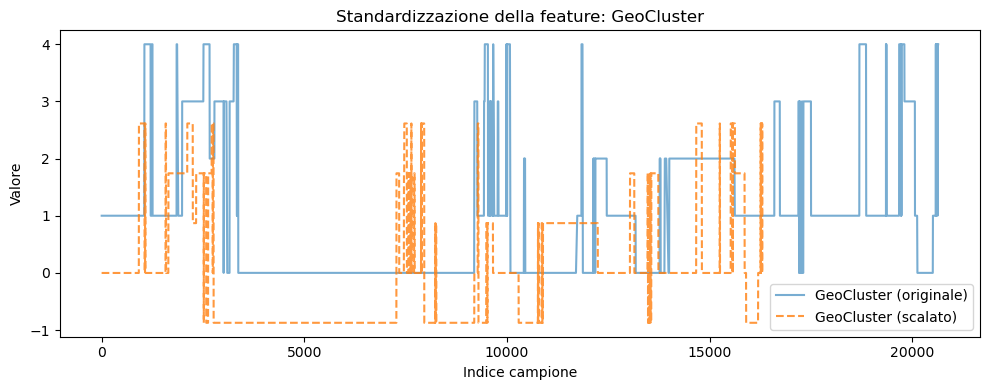

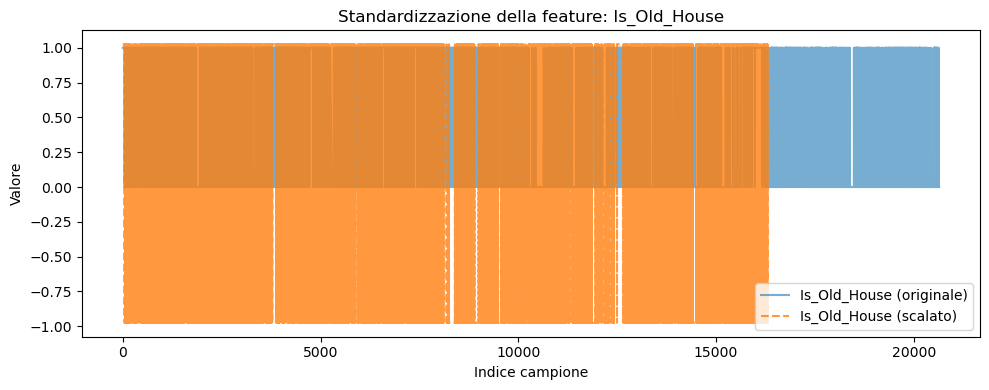

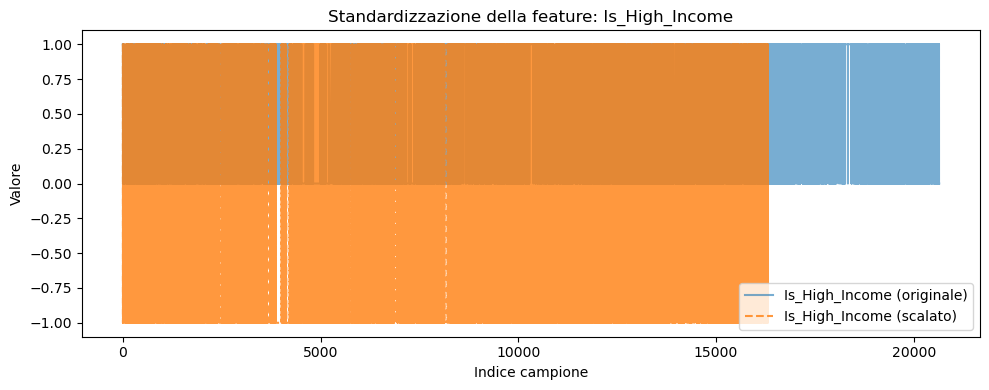

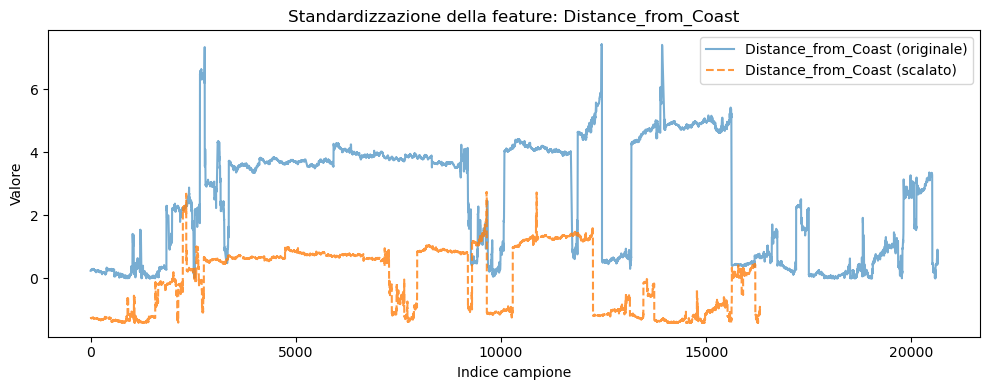

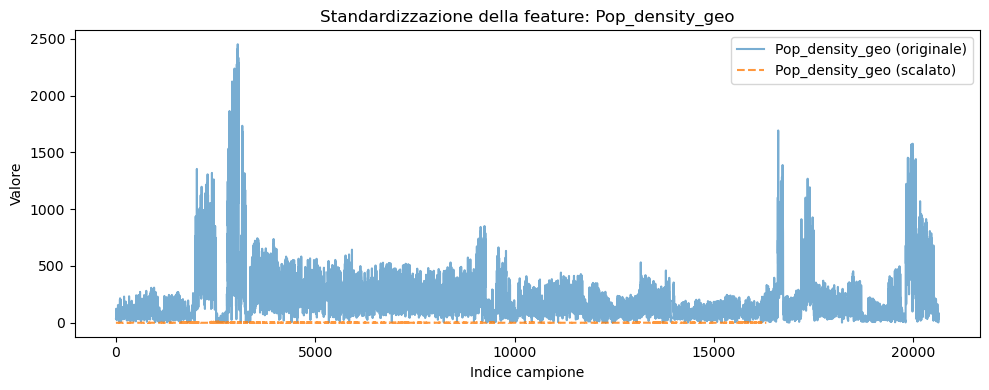

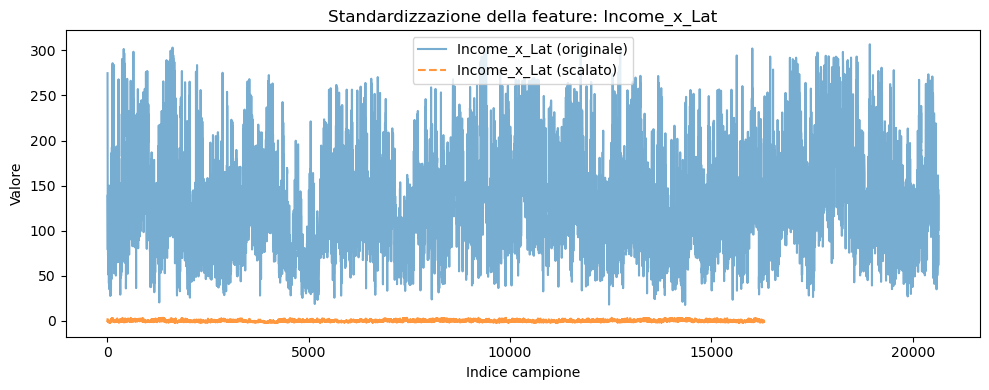

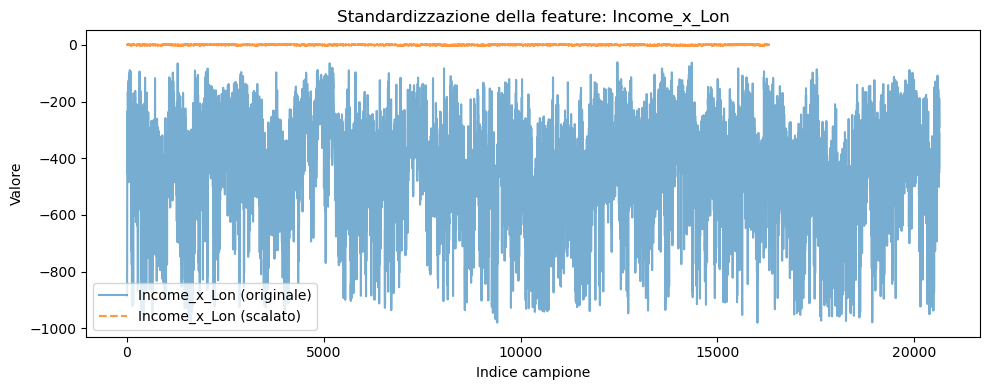

In [79]:
# Converto in DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

for col in X.columns:
    plt.figure(figsize=(10, 4))
    
    plt.plot(X.index, X[col], label=f"{col} (originale)", alpha=0.6)
    plt.plot(X_scaled_df.index, X_scaled_df[col], label=f"{col} (scalato)", linestyle='--', alpha=0.8)
    
    plt.title(f"Standardizzazione della feature: {col}")
    plt.xlabel("Indice campione")
    plt.ylabel("Valore")
    
    plt.legend()
    plt.tight_layout()
    plt.show()

## Funzione di valutazione

Valuta un modello di regressione usando:
- KFold cross-validation se cv è fornito
- Train/Test split se train_test_split_ratio è fornito (es. 0.8)
    
Restituisce un dizionario con:
- MSE_mean
- MSE_std
- RMSE_mean
- RMSE_std
- R2_mean
- R2_std

### Esempio d'uso

Con KFold:
- kf = KFold(n_splits=5, shuffle=True, random_state=42)
- scores = evaluate_model_reg(model, X, y, cv=kf)

Con train/test split 80/20:
- scores_split = evaluate_model_reg(model, X, y, train_test_split_ratio=0.8)

In [80]:
def evaluate_model_reg(model, X_scaled, cv=None, train_test_split_ratio=None, random_state=42):
    scores_mse, scores_rmse, scores_r2 = [], [], []

    # Se X_scaled è fornito, usalo; altrimenti scala dentro la funzione
    if X_scaled is not None:
        X_to_use = X_scaled
        y_to_use = y
    else:
        scaler = StandardScaler()
        X_to_use = scaler.fit_transform(X)
        y_to_use = (y - y.mean()) / y.std()

    if cv is not None:
        
        for train_idx, test_idx in cv.split(X_to_use):
            X_train, X_test = X_to_use[train_idx], X_to_use[test_idx]
            y_train, y_test = y_to_use.iloc[train_idx], y_to_use.iloc[test_idx]


            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            scores_mse.append(mean_squared_error(y_test, y_pred))
            scores_rmse.append(np.sqrt(mean_squared_error(y_test, y_pred)))
            scores_r2.append(r2_score(y_test, y_pred))

    elif train_test_split_ratio is not None:
        
        train_idx, test_idx = train_test_split(np.arange(len(y_to_use)), train_size=train_test_split_ratio, random_state=random_state)
        
        X_train, X_test = X_to_use[train_idx], X_to_use[test_idx]
        y_train, y_test = y_to_use.iloc[train_idx], y_to_use.iloc[test_idx]


        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        scores_mse.append(mean_squared_error(y_test, y_pred))
        scores_rmse.append(np.sqrt(mean_squared_error(y_test, y_pred)))
        scores_r2.append(r2_score(y_test, y_pred))

    else:
        raise ValueError("Devi fornire cv oppure train_test_split_ratio")

    return {
        "MSE_mean": np.mean(scores_mse),
        "MSE_std": np.std(scores_mse),
        "RMSE_mean": np.mean(scores_rmse),
        "RMSE_std": np.std(scores_rmse),
        "R2_mean": np.mean(scores_r2),
        "R2_std": np.std(scores_r2)
    }


## Definizione CV

In [81]:
kf = KFold(n_splits=3, shuffle=True, random_state=42)

## Lista modelli

In [82]:
models = {
    "LinearRegression": LinearRegression(),
    "Lasso": Lasso(alpha=0.1, max_iter=5000, random_state=42),
    "Ridge": Ridge(alpha=1.0, max_iter=5000, random_state=42)
}

## Valutazione modelli lineari

In [83]:
results = []

for name, model in models.items():
    # Train/Test Split
    scores_split = evaluate_model_reg(model, X_scaled, train_test_split_ratio=0.8)
    scores_split["model"] = name
    scores_split["setting"] = "Train/Test Split 80/20"
    results.append(scores_split)

    # KFold
    scores_kf = evaluate_model_reg(model, X_scaled, cv=kf)
    scores_kf["model"] = name
    scores_kf["setting"] = "KFold 3-fold"
    results.append(scores_kf)

## XGBoost con combinazioni iperparametri

In [84]:
xgb_param_grid = [
    {"n_estimators": 50, "max_depth": 3},
    {"n_estimators": 100, "max_depth": 3},
    {"n_estimators": 100, "max_depth": 5},
]

for params in xgb_param_grid:
    model = XGBRegressor(**params, random_state=42, n_jobs=-1, verbosity=0)

    # Train/Test Split
    scores_split = evaluate_model_reg(model, X_scaled, train_test_split_ratio=0.8)
    scores_split["model"] = f"XGBoost (n={params['n_estimators']}, d={params['max_depth']})"
    scores_split["setting"] = "Train/Test Split 80/20"
    results.append(scores_split)

    # KFold
    scores_kf = evaluate_model_reg(model, X_scaled, cv=kf)
    scores_kf["model"] = f"XGBoost (n={params['n_estimators']}, d={params['max_depth']})"
    scores_kf["setting"] = "KFold 3-fold"
    results.append(scores_kf)

# TABELLA RISULTATI

In [85]:
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by="RMSE_mean")
display(df_results.style.hide(axis="index"))

MSE_mean,MSE_std,RMSE_mean,RMSE_std,R2_mean,R2_std,model,setting
0.162454,0.000000,0.403056,0.000000,0.814151,0.000000,"XGBoost (n=100, d=5)",Train/Test Split 80/20
0.169610,0.005155,0.411790,0.006268,0.809620,0.002691,"XGBoost (n=100, d=5)",KFold 3-fold
0.182738,0.000000,0.427479,0.000000,0.790946,0.000000,"XGBoost (n=100, d=3)",Train/Test Split 80/20
0.187273,0.006729,0.432680,0.007798,0.789814,0.004114,"XGBoost (n=100, d=3)",KFold 3-fold
0.199474,0.000000,0.446625,0.000000,0.771800,0.000000,"XGBoost (n=50, d=3)",Train/Test Split 80/20
0.205903,0.007358,0.453692,0.008115,0.768903,0.004535,"XGBoost (n=50, d=3)",KFold 3-fold
0.323600,0.000000,0.568859,0.000000,0.629799,0.000000,LinearRegression,Train/Test Split 80/20
0.325619,0.000000,0.570630,0.000000,0.627490,0.000000,Ridge,Train/Test Split 80/20
0.328705,0.006512,0.573300,0.005699,0.630974,0.002477,LinearRegression,KFold 3-fold
0.332822,0.006953,0.576875,0.006049,0.626359,0.002647,Ridge,KFold 3-fold


# XGBoost + Optuna

In [86]:
import optuna
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np

def objective(trial, X, y):

    train_x, valid_x, train_y, valid_y = train_test_split(
        X, y, test_size=0.25, random_state=42
    )

    params = {
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "tree_method": "hist",
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 1e-8, 1.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_lambda": trial.suggest_float("lambda", 1e-8, 10.0, log=True),
        "reg_alpha": trial.suggest_float("alpha", 1e-8, 10.0, log=True),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "n_estimators": 300,
        "random_state": 42,
    }

    # Passaggio corretto dei parametri
    model = xgb.XGBRegressor(**params)

    model.fit(
        train_x,
        train_y,
        eval_set=[(valid_x, valid_y)],
        verbose=False
    )

    preds = model.predict(valid_x)
    rmse = np.sqrt(mean_squared_error(valid_y, preds))

    return rmse

# Creazione dello study
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5)
)

print("Inizio Tuning con Optuna...")
study.optimize(lambda trial: objective(trial, X, y), n_trials=100, timeout=3600)

print("Migliori parametri:", study.best_params)
print("Miglior RMSE:", study.best_value)

optuna.visualization.plot_param_importances(study).show()

Inizio Tuning con Optuna...


Exception ignored in: <function ResourceTracker.__del__ at 0x102d91bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106dc9bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x118195bc0>
Traceback (most recent call last

Migliori parametri: {'max_depth': 9, 'min_child_weight': 8, 'gamma': 0.0002016366241683609, 'subsample': 0.9089125373806795, 'colsample_bytree': 0.832019487458363, 'lambda': 2.566157980659018e-07, 'alpha': 0.02106004996226576, 'learning_rate': 0.061396148911268184}
Miglior RMSE: 0.3761199658798903


# Workflow Finale

In [87]:
import optuna
import xgboost as xgb
import numpy as np
import warnings
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Setup pulizia output
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

# ==========================================
# 1. Caricamento Dati (California Housing)
# ==========================================
print("--- Caricamento California Housing Dataset ---")
# data = fetch_california_housing()
# X, y = data.data, data.target

# X = 8 feature (MedInc, HouseAge, AveRooms, etc.)
# y = Prezzo mediano (in centinaia di migliaia di $)

# Split Train/Test (Test set intoccabile fino alla fine)
X_train_full, X_test, y_train_full, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Dataset Shape: {X.shape}")
print(f"Target medio: {np.mean(y):.2f} (centinaia di k$)")

# ==========================================
# 2. Baseline (Senza Tuning)
# ==========================================
print("\n--- Training Modello Baseline (Default) ---")
dtrain_full = xgb.DMatrix(X_train_full, label=y_train_full)
dtest = xgb.DMatrix(X_test, label=y_test)

# Parametri standard di default
params_base = {
    'objective': 'reg:squarederror', # Regressione
    'tree_method': 'hist',
    'random_state': 42
}

model_base = xgb.train(params_base, dtrain_full, num_boost_round=100)
preds_base = model_base.predict(dtest)

# Calcolo RMSE Baseline
rmse_base = np.sqrt(mean_squared_error(y_test, preds_base))
print(f"Baseline RMSE: {rmse_base:.4f}")


# ==========================================
# 3. Ottimizzazione con Optuna
# ==========================================
print("\n--- Inizio Tuning con Optuna ---")

def objective(trial):
    # Split interno per validazione durante il tuning
    X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)
    
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dvalid = xgb.DMatrix(X_valid, label=y_valid)

    # Spazio di ricerca
    param = {
        'verbosity': 0,
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse', # Metrica per early stopping e pruning
        'tree_method': 'hist',
        
        # --- Struttura ---
        # California ha interazioni complesse, permettiamo alberi più profondi
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        # Importante per evitare overfitting su outlier di prezzo
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        
        # --- Randomness ---
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        
        # --- Regolarizzazione ---
        # Fondamentale nella regressione per non inseguire i prezzi estremi
        'lambda': trial.suggest_float('lambda', 1e-8, 20.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-8, 20.0, log=True),
        
        # --- Learning ---
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
    }

    # Pruning basato su RMSE
    pruning_callback = optuna.integration.XGBoostPruningCallback(trial, "validation-rmse")

    model = xgb.train(
        param,
        dtrain,
        num_boost_round=1000,
        evals=[(dvalid, "validation")],
        early_stopping_rounds=50,
        callbacks=[pruning_callback],
        verbose_eval=False
    )

    # Optuna deve minimizzare RMSE
    preds = model.predict(dvalid)
    rmse = np.sqrt(mean_squared_error(y_valid, preds))
    return rmse

# Creazione Studio (Minimizzare RMSE)
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, timeout=600)

print(f"\nMiglior RMSE trovato da Optuna (Validation): {study.best_value:.4f}")
print("Migliori parametri:", study.best_params)


# ==========================================
# 4. Training Modello Finale (Best Params + Shrinkage)
# ==========================================
print("\n--- Training Modello Finale Ottimizzato ---")

best_params = study.best_params
best_params['objective'] = 'reg:squarederror'
best_params['eval_metric'] = 'rmse'
best_params['tree_method'] = 'hist'

# STRATEGIA "SHRINKAGE" (Raffiniamo la discesa del gradiente)
# Abbassiamo il learning rate trovato per maggiore precisione finale
best_params['learning_rate'] = best_params['learning_rate'] * 0.5 
# Aumentiamo gli alberi di conseguenza (safety buffer alto, early stopping gestirà il resto)
num_round_final = 5000 

model_opt = xgb.train(
    best_params, 
    dtrain_full, 
    num_boost_round=num_round_final,
    evals=[(dtest, "test")], # Test set usato SOLO per fermare il training al punto giusto
    early_stopping_rounds=100,
    verbose_eval=False
)

# ==========================================
# 5. Analisi Risultati
# ==========================================
print("\n--- CONFRONTO FINALE ---")

preds_opt = model_opt.predict(dtest)
rmse_opt = np.sqrt(mean_squared_error(y_test, preds_opt))

# R2 Score (coefficiente di determinazione)
r2_base = r2_score(y_test, preds_base)
r2_opt = r2_score(y_test, preds_opt)

print(f"RMSE Baseline:    {rmse_base:.4f}")
print(f"RMSE Ottimizzato: {rmse_opt:.4f}")
print(f"--> Miglioramento Errore: {rmse_base - rmse_opt:.4f} (Minore è meglio)")
print("-" * 30)
print(f"R2 Score Baseline:    {r2_base:.4f}")
print(f"R2 Score Ottimizzato: {r2_opt:.4f}")
print(f"--> Varianza Spiegata Extra: +{(r2_opt - r2_base)*100:.2f}%")

--- Caricamento California Housing Dataset ---
Dataset Shape: (16312, 32)
Target medio: 1.93 (centinaia di k$)

--- Training Modello Baseline (Default) ---
Baseline RMSE: 0.4046

--- Inizio Tuning con Optuna ---


Exception ignored in: <function ResourceTracker.__del__ at 0x103951bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104ef5bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes



Miglior RMSE trovato da Optuna (Validation): 0.4069
Migliori parametri: {'max_depth': 8, 'min_child_weight': 10, 'gamma': 1.9321685430321768e-07, 'subsample': 0.9946504575481243, 'colsample_bytree': 0.9008283558471748, 'lambda': 2.303345215616004, 'alpha': 0.005725091054952895, 'learning_rate': 0.1190826489025577}

--- Training Modello Finale Ottimizzato ---

--- CONFRONTO FINALE ---
RMSE Baseline:    0.4046
RMSE Ottimizzato: 0.3814
--> Miglioramento Errore: 0.0231 (Minore è meglio)
------------------------------
R2 Score Baseline:    0.8127
R2 Score Ottimizzato: 0.8335
--> Varianza Spiegata Extra: +2.08%


# LightGBM

In [88]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd

#X = df_clean.drop("MedHouseVal", axis=1)
#y = df_clean["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

from lightgbm import early_stopping

lgbm = LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    random_state=42
)

lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="rmse",
    callbacks=[early_stopping(100)],
)

y_pred = lgbm.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

importance = pd.Series(
    lgbm.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nTop 20 Feature Importance:")
print(importance.head(20))

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1251]	valid_0's rmse: 0.374415	valid_0's l2: 0.140186
R2: 0.8396257556982277
RMSE: 0.3744148396681105

Top 20 Feature Importance:
Lat_plus_Lon               3556
Latitude                   2629
AveBedrms                  2315
Distance_from_Center       2198
Longitude                  1961
Bedrooms_per_Room          1949
Income_x_HouseAge          1836
Lat_minus_Lon              1673
Pop_density_geo            1639
AveRooms_x_Age             1562
Rooms_per_HouseAge         1452
MedInc_x_AveBedrms         1449
Bedrooms_per_Person        1444
MedInc_x_AveRooms          1399
People_per_Room            1366
Population_per_HouseAge    1364
AveRooms                   1358
Income_per_HouseAge        1349
Income_x_Lat               1016
Distance_from_Coast         895
dtype: int32


# CatBoost

In [89]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import pandas as pd

#X = df_clean.drop("MedHouseVal", axis=1)
#y = df_clean["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

cat = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    random_seed=42,
    verbose=200,
    early_stopping_rounds=100
)

cat.fit(
    X_train, y_train,
    eval_set=(X_test, y_test)
)

y_pred = cat.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

importance = pd.Series(
    cat.get_feature_importance(),
    index=X.columns
).sort_values(ascending=False)

print("\nTop 20 Feature Importance (CatBoost):")
print(importance.head(20))

0:	learn: 0.9176088	test: 0.9071700	best: 0.9071700 (0)	total: 35ms	remaining: 1m 9s
200:	learn: 0.4011082	test: 0.4253637	best: 0.4253637 (200)	total: 1.37s	remaining: 12.3s
400:	learn: 0.3439667	test: 0.3988665	best: 0.3988665 (400)	total: 2.67s	remaining: 10.6s
600:	learn: 0.3087237	test: 0.3875428	best: 0.3875163 (599)	total: 4.12s	remaining: 9.59s
800:	learn: 0.2811224	test: 0.3804251	best: 0.3804239 (799)	total: 5.38s	remaining: 8.05s
1000:	learn: 0.2589965	test: 0.3760385	best: 0.3760385 (1000)	total: 6.61s	remaining: 6.6s
1200:	learn: 0.2397068	test: 0.3734265	best: 0.3734265 (1200)	total: 7.89s	remaining: 5.25s
1400:	learn: 0.2235177	test: 0.3719250	best: 0.3718878 (1397)	total: 9.1s	remaining: 3.89s
1600:	learn: 0.2086554	test: 0.3710129	best: 0.3710030 (1598)	total: 10.5s	remaining: 2.61s
1800:	learn: 0.1956218	test: 0.3698988	best: 0.3698987 (1798)	total: 11.8s	remaining: 1.3s
1999:	learn: 0.1838562	test: 0.3686088	best: 0.3685949 (1996)	total: 13s	remaining: 0us

bestTest 

# Ensemble a Media Ponderata (Weighted Blending)

In [90]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Import dei Regressori
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

# 1. Caricamento e Preparazione Dati
# ---------------------------------------------------------
print("Caricamento dataset California Housing...")
# data = fetch_california_housing()
# X = pd.DataFrame(data.data, columns=data.feature_names)
# y = data.target

# Split 80/20 standard
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# 2. Definizione dei Modelli (Base Parameters)
# ---------------------------------------------------------
# Nota: Qui usiamo parametri "sensati" ma statici. 
# In produzione, questi verrebbero iniettati dopo uno studio Optuna.

params_common = {'random_state': 42}

# XGBoost
xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    n_jobs=-1,
    **params_common
)

# CatBoost (verbose=0 per silenziare l'output durante il training)
cat_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    verbose=0,
    allow_writing_files=False,
    **params_common
)

# LightGBM
lgbm_model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    n_jobs=-1,
    verbose=-1, # Silenzia i warning
    **params_common
)

# 3. Training
# ---------------------------------------------------------
print("Addestramento modelli in corso...")

xgb_model.fit(X_train, y_train)
print(f"XGBoost completato.")

cat_model.fit(X_train, y_train)
print(f"CatBoost completato.")

lgbm_model.fit(X_train, y_train)
print(f"LightGBM completato.")

# 4. Predizione e Ensemble (Weighted Blending)
# ---------------------------------------------------------
# Generiamo le predizioni individuali sul Test Set
preds_xgb = xgb_model.predict(X_test)
preds_cat = cat_model.predict(X_test)
preds_lgbm = lgbm_model.predict(X_test)

# Definizione dei pesi specificati
w_xgb = 0.4
w_cat = 0.2
w_lgbm = 0.4

# Calcolo della predizione combinata
# Formula: y_pred = (0.4 * XGB) + (0.2 * CAT) + (0.4 * LGBM)
preds_ensemble = (preds_xgb * w_xgb) + (preds_cat * w_cat) + (preds_lgbm * w_lgbm)

# 5. Valutazione e Confronto
# ---------------------------------------------------------
def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{model_name:<15} | RMSE: {rmse:.4f}")

print("\n--- Risultati (RMSE più basso è migliore) ---")
evaluate(y_test, preds_xgb, "XGBoost")
evaluate(y_test, preds_cat, "CatBoost")
evaluate(y_test, preds_lgbm, "LightGBM")
print("-" * 35)
evaluate(y_test, preds_ensemble, "Ensemble (Blend)")

Caricamento dataset California Housing...
Addestramento modelli in corso...
XGBoost completato.
CatBoost completato.
LightGBM completato.

--- Risultati (RMSE più basso è migliore) ---
XGBoost         | RMSE: 0.3766
CatBoost        | RMSE: 0.3859
LightGBM        | RMSE: 0.3754
-----------------------------------
Ensemble (Blend) | RMSE: 0.3712


## Il Meta-Learner

In [91]:
import numpy as np
import pandas as pd
import optuna
import logging
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Modelli
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

# Stacking
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV

# Configurazione Silenziosa
optuna.logging.set_verbosity(optuna.logging.WARNING)
import warnings
warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# 1. PREPARAZIONE DATI
# ---------------------------------------------------------
print("1. Caricamento e split dati...")
# data = fetch_california_housing()
# X = pd.DataFrame(data.data, columns=data.feature_names)
# y = data.target

# Split Principale: 80% Train (per Optuna + Stacking), 20% Test (Hold-out finale)
X_train_full, X_test, y_train_full, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Split Secondario: Solo per Optuna (per non overfittare sul train set intero durante il tuning)
X_opt_train, X_opt_val, y_opt_train, y_opt_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42
)

# ---------------------------------------------------------
# 2. OTTIMIZZAZIONE OPTUNA (LIGHT)
# ---------------------------------------------------------
print("2. Avvio Ottimizzazione Iperparametri (20 trial per modello)...")

# --- XGBoost ---
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'n_jobs': -1,
        'random_state': 42,
    }
    model = XGBRegressor(**params)
    model.fit(X_opt_train, y_opt_train)
    preds = model.predict(X_opt_val)
    return np.sqrt(mean_squared_error(y_opt_val, preds))

study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=20, show_progress_bar=True)
best_xgb_params = study_xgb.best_params
best_xgb_params.update({'n_jobs': -1, 'random_state': 42}) # Reinseriamo params statici

# --- CatBoost ---
def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 500, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'verbose': 0,
        'allow_writing_files': False,
        'random_state': 42
    }
    model = CatBoostRegressor(**params)
    model.fit(X_opt_train, y_opt_train)
    preds = model.predict(X_opt_val)
    return np.sqrt(mean_squared_error(y_opt_val, preds))

study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(objective_cat, n_trials=20, show_progress_bar=True)
best_cat_params = study_cat.best_params
best_cat_params.update({'verbose': 0, 'allow_writing_files': False, 'random_state': 42})

# --- LightGBM ---
def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', -1, 15),
        'n_jobs': -1,
        'verbose': -1,
        'random_state': 42
    }
    model = LGBMRegressor(**params)
    model.fit(X_opt_train, y_opt_train)
    preds = model.predict(X_opt_val)
    return np.sqrt(mean_squared_error(y_opt_val, preds))

study_lgbm = optuna.create_study(direction='minimize')
study_lgbm.optimize(objective_lgbm, n_trials=20, show_progress_bar=True)
best_lgbm_params = study_lgbm.best_params
best_lgbm_params.update({'n_jobs': -1, 'verbose': -1, 'random_state': 42})

print(f"\nBest RMSE Val -> XGB: {study_xgb.best_value:.4f} | CAT: {study_cat.best_value:.4f} | LGBM: {study_lgbm.best_value:.4f}")

# ---------------------------------------------------------
# 3. COSTRUZIONE E TRAINING STACKING REGRESSOR
# ---------------------------------------------------------
print("\n3. Configurazione Stacking Regressor con i migliori parametri...")

# Definizione Level 0 (Base Models)
estimators = [
    ('xgb', XGBRegressor(**best_xgb_params)),
    ('cat', CatBoostRegressor(**best_cat_params)),
    ('lgbm', LGBMRegressor(**best_lgbm_params))
]

# Definizione Level 1 (Meta Model)
# RidgeCV trova automaticamente la regolarizzazione (alpha) migliore
meta_learner = RidgeCV(alphas=[0.1, 1.0, 10.0])

stacking_regressor = StackingRegressor(
    estimators=estimators,
    final_estimator=meta_learner,
    cv=5,            # 5-Fold per generare le previsioni out-of-fold robuste
    n_jobs=-1,
    passthrough=False 
)

print("Addestramento Stacking (questo passaggio ri-addestra i base models su 5 fold)...")
stacking_regressor.fit(X_train_full, y_train_full)

# ---------------------------------------------------------
# 4. VALUTAZIONE FINALE
# ---------------------------------------------------------
print("\n4. Valutazione sul Test Set (Hold-out)...")

# Predizione
preds = stacking_regressor.predict(X_test)

# Metriche
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("-" * 40)
print(f"STACKING FINAL RMSE: {rmse:.4f}")
print(f"STACKING FINAL R2:   {r2:.4f}")
print("-" * 40)

# Ispezione Pesi Meta-Learner
print("Pesi assegnati dal Meta-Modello (Ridge):")
print(f"Intercept: {stacking_regressor.final_estimator_.intercept_:.4f}")
model_names = ['XGBoost', 'CatBoost', 'LightGBM']
coeffs = stacking_regressor.final_estimator_.coef_

for name, coef in zip(model_names, coeffs):
    print(f"{name:<10}: {coef:.4f}")

1. Caricamento e split dati...
2. Avvio Ottimizzazione Iperparametri (20 trial per modello)...


  0%|          | 0/20 [00:00<?, ?it/s]

Exception ignored in: <function ResourceTracker.__del__ at 0x1049a5bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10551dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


  0%|          | 0/20 [00:00<?, ?it/s]

Exception ignored in: <function ResourceTracker.__del__ at 0x102d35bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


  0%|          | 0/20 [00:00<?, ?it/s]


Best RMSE Val -> XGB: 0.4065 | CAT: 0.4121 | LGBM: 0.4083

3. Configurazione Stacking Regressor con i migliori parametri...
Addestramento Stacking (questo passaggio ri-addestra i base models su 5 fold)...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



4. Valutazione sul Test Set (Hold-out)...
----------------------------------------
STACKING FINAL RMSE: 0.3672
STACKING FINAL R2:   0.8458
----------------------------------------
Pesi assegnati dal Meta-Modello (Ridge):
Intercept: -0.0282
XGBoost   : 0.3268
CatBoost  : 0.3953
LightGBM  : 0.2928
